<a href="https://colab.research.google.com/github/HiyoriVn/CSE_Machine-Learning/blob/main/Perceptron_Learning_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import base64

plt.rcParams['animation.embed_limit'] = 50

In [6]:
np.random.seed(2)

means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
N = 10
X0 = np.random.multivariate_normal(means[0], cov, N).T
X1 = np.random.multivariate_normal(means[1], cov, N).T

X = np.concatenate((X0, X1), axis=1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis=1)

# Xbar
X = np.concatenate((np.ones((1, 2*N)), X), axis=0)

In [7]:
def h(w, x):
    return np.sign(np.dot(w.T, x))

def has_converged(X, y, w):
    return np.array_equal(h(w, X), y)

def perceptron(X, y, w_init):
    w = [w_init]
    N = X.shape[1]
    mis_points = []
    while True:
        mix_id = np.random.permutation(N)
        for i in range(N):
            xi = X[:, mix_id[i]].reshape(3, 1)
            yi = y[0, mix_id[i]]
            if h(w[-1], xi)[0] != yi:
                mis_points.append(mix_id[i])
                w_new = w[-1] + yi*xi
                w.append(w_new)

        if has_converged(X, y, w[-1]):
            break
    return (w, mis_points)

In [8]:
d = X.shape[0]
w_init = np.random.randn(d, 1)
(w, m) = perceptron(X, y, w_init)
print("Các điểm bị phân loại sai qua từng bước cập nhật:", m)
print("Số lần cập nhật w:", len(w))

Các điểm bị phân loại sai qua từng bước cập nhật: [np.int64(7), np.int64(10), np.int64(0), np.int64(18), np.int64(3), np.int64(6), np.int64(14), np.int64(9), np.int64(7), np.int64(17), np.int64(0), np.int64(19), np.int64(3), np.int64(2), np.int64(12), np.int64(6), np.int64(11), np.int64(7)]
Số lần cập nhật w: 19


In [9]:
def draw_line(w, ax):
    w0, w1, w2 = w[0], w[1], w[2]
    if w2 != 0:
        x11, x12 = -100, 100
        ax.plot([x11, x12], [-(w1*x11 + w0)/w2, -(w1*x12 + w0)/w2], 'k')
    else:
        x10 = -w0/w1
        ax.plot([x10, x10], [-100, 100], 'k')

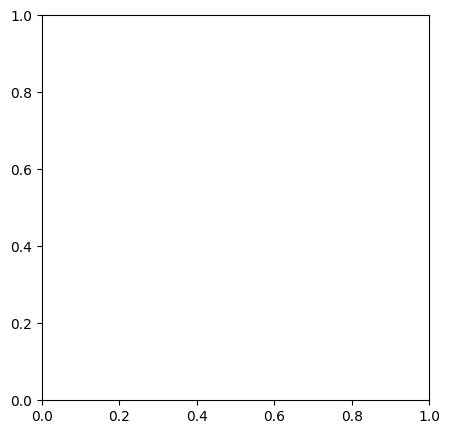

In [10]:
it = len(w)
fig, ax = plt.subplots(figsize=(5, 5))

def init():
    ax.clear()
    ax.plot(X0[0, :], X0[1, :], 'b^', markersize=8, alpha=.8)
    ax.plot(X1[0, :], X1[1, :], 'ro', markersize=8, alpha=.8)
    ax.axis([0, 6, -2, 4])
    ax.set_xticks([])
    ax.set_yticks([])
    return []

def update(i):
    ax.clear()

    # points
    ax.plot(X0[0, :], X0[1, :], 'b^', markersize=8, alpha=.8)
    ax.plot(X1[0, :], X1[1, :], 'ro', markersize=8, alpha=.8)
    ax.axis([0, 6, -2, 4])

    i2 = i if i < it else it - 1
    draw_line(w[i2], ax)

    if i < it - 1:
        circle = plt.Circle((X[1, m[i]], X[2, m[i]]), 0.15, color='k', fill=False)
        ax.add_artist(circle)

    ax.set_xticks([])
    ax.set_yticks([])

    label = 'PLA: iter %d/%d' % (i2, it - 1)
    ax.set_xlabel(label)
    return []


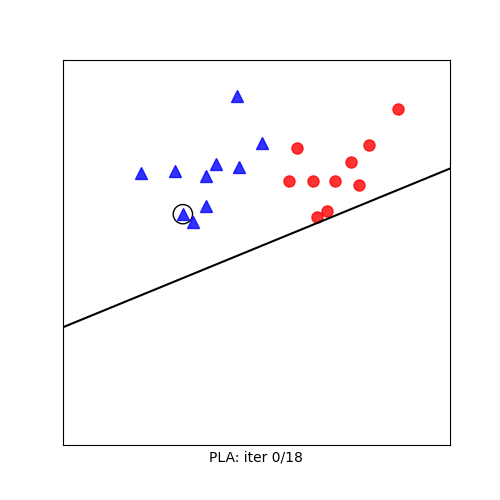

In [11]:
anim = FuncAnimation(fig, update, init_func=init,
                      frames=np.arange(0, it + 2), interval=1000)
plt.close(fig)

anim.save('pla_vis.gif', dpi=100, writer='pillow')

with open('pla_vis.gif', 'rb') as f:
    b64 = base64.b64encode(f.read()).decode('ascii')

HTML(f'<img src="data:image/gif;base64,{b64}" />')